# Model Selection and Cross-Validation

This tutorial shows how to compare estimator-style models with `qml.model_selection` on user-supplied arrays.

The helper functions use deterministic sklearn splitters and package-owned scoring summaries. The small defaults here are for API demonstration, not performance claims.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "tutorials":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from qml import QuantumReservoirClassifier, select_best_model, train_test_evaluate
from qml.model_selection import cross_validate_estimator
from qml.reporting import print_table


## Dataset

In [2]:
x_raw, y = make_moons(n_samples=48, noise=0.14, random_state=21)
x = StandardScaler().fit_transform(x_raw)

print_table(
    {
        "dataset": "moons",
        "samples": int(x.shape[0]),
        "features": int(x.shape[1]),
        "classes": np.unique(y).tolist(),
    },
    title="Dataset",
)


Dataset
+----------+--------+
| Metric   | Value  |
+----------+--------+
| dataset  | moons  |
| samples  | 48     |
| features | 2      |
| classes  | [0, 1] |
+----------+--------+



## Cross-validate candidates

In [3]:
candidates = {
    "logistic": LogisticRegression(max_iter=1000),
    "reservoir": QuantumReservoirClassifier(seed=21, max_iter=1000),
}

selection = select_best_model(
    candidates,
    x,
    y,
    cv=3,
    task="classification",
    scoring="accuracy",
    seed=21,
)

summary_rows = []
for candidate in selection["candidates"]:
    stats = candidate["cv_result"]["summary"]["test_score"]
    summary_rows.append(
        {
            "model": candidate["name"],
            "mean_accuracy": stats["mean"],
            "ci95_low": stats["ci95_low"],
            "ci95_high": stats["ci95_high"],
            "folds": stats["n"],
        }
    )

print_table(
    summary_rows,
    columns=["model", "mean_accuracy", "ci95_low", "ci95_high", "folds"],
    title="Cross-validation summary",
)
print_table({"best_model": selection["best_name"], "best_score": selection["best_score"]}, title="Selection")


Cross-validation summary
+-----------+---------------+----------+-----------+-------+
| model     | mean_accuracy | ci95_low | ci95_high | folds |
+-----------+---------------+----------+-----------+-------+
| logistic  | 0.8125        | 0.659716 | 0.965284  | 3     |
| reservoir | 0.5           | 0.442253 | 0.557747  | 3     |
+-----------+---------------+----------+-----------+-------+

Selection
+------------+----------+
| Metric     | Value    |
+------------+----------+
| best_model | logistic |
| best_score | 0.8125   |
+------------+----------+



## Inspect one model directly

In [4]:
reservoir_cv = cross_validate_estimator(
    QuantumReservoirClassifier(seed=7, max_iter=1000),
    x,
    y,
    cv=3,
    task="classification",
    scoring="accuracy",
    seed=7,
)

fold_rows = [
    {
        "fold": fold["fold"],
        "train_score": fold["train_score"],
        "test_score": fold["test_score"],
        "fit_seconds": fold["fit_seconds"],
    }
    for fold in reservoir_cv["folds"]
]
print_table(fold_rows, columns=["fold", "train_score", "test_score", "fit_seconds"], title="Reservoir folds")


Reservoir folds
+------+-------------+------------+-------------+
| fold | train_score | test_score | fit_seconds |
+------+-------------+------------+-------------+
| 1    | 0.625       | 0.6875     | 0.0892158   |
| 2    | 0.6875      | 0.5625     | 0.0730951   |
| 3    | 0.625       | 0.625      | 0.0802958   |
+------+-------------+------------+-------------+



## Final train/test evaluation

In [5]:
final_result = train_test_evaluate(
    candidates[selection["best_name"]],
    x,
    y,
    test_size=0.25,
    task="classification",
    scoring="accuracy",
    seed=21,
)

print_table(
    {
        "model": selection["best_name"],
        "train_size": final_result["train_size"],
        "test_size": final_result["test_size"],
        "train_accuracy": final_result["train_score"],
        "test_accuracy": final_result["test_score"],
    },
    title="Final split",
)


Final split
+----------------+----------+
| Metric         | Value    |
+----------------+----------+
| model          | logistic |
| train_size     | 36       |
| test_size      | 12       |
| train_accuracy | 0.861111 |
| test_accuracy  | 0.833333 |
+----------------+----------+



## Plot the cross-validation comparison

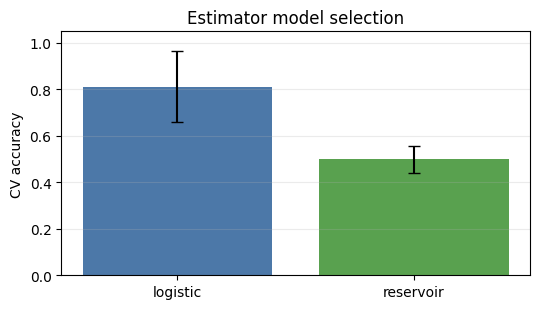

In [6]:
labels = [row["model"] for row in summary_rows]
means = np.asarray([row["mean_accuracy"] for row in summary_rows])
lower = means - np.asarray([row["ci95_low"] for row in summary_rows])
upper = np.asarray([row["ci95_high"] for row in summary_rows]) - means

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.bar(labels, means, yerr=[lower, upper], color=["#4c78a8", "#59a14f"], capsize=4)
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("CV accuracy")
ax.set_title("Estimator model selection")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()
